# ***2026 1학기 제주도 교육청 고교학점제 인공지능수학 수행평가***
- 본 수행평가는 평가 계획서에 예고된대로 3개 영역으로 구성됩니다
  - 텍스트 처리 영역
  - 이미지 처리 영역
  - 추세선 최적화 영역

## ***1. 텍스트 처리 영역***

다음과 같이 긍정 단어 가방, 부정 단어 가방, 중립 단어 가방이 주어져 있습니다

***긍정 단어가방***
```text
재밌다, 최고, 만족, 깨끗, 친절, 아름답다, 추천, 행복, 감동, 인상적
```

***부정 단어가방***
```text
피곤, 강풍, 지연, 결항, 혼잡, 실망, 불편, 아쉽다, 지루, 불쾌
```

***중립 단어가방***
```text
제주, 바다, 날씨, 버스, 택시, 비행기, 관광지, 숙소, 카페, 이동
```

다음은 제주 방문객의 여행 후기 입니다

***여행자1***
```
제주의 날씨는 여행 내내 너무 좋았다
숙소에서 보이는 바다뷰가 아름답고 객실도 깨끗해서 만족스러웠다.
관광지에서는 전반적으로 혼잡했지만 친절하게 대해주셨고 사진 찍기에도 좋았다.  
버스 시스템이 매우 잘 되어 있어서 이동하는 거리도 생각보다 편했고 여행하는 내내 행복했다.
돌아오는 비행기는 강풍으로 지연이 되기는 했지만 다행히 잘 돌아왔다.
전반적으로 만족스러운 여행이었다
```

***여행자2***
```
출발부터 뭔가 심상치 않았다
지연통보를 받았고 공항은 혼잡했다
결국 비행기는 연착되었고 숙소까지 택시를 타고 가야 했다
택시 요금이 비싸게 나왔지만 기사님이 친절했다
관광지는 아름답다고 소문난 곳이어서 만족했다
돌아오는 비행기는 강풍으로 결항되어 숙소를 다시 잡아야 해서 불편했다
그래도 숙소는 깨끗했다
전체적으로 여행이 지루하고 실망스러웠으나 자연의 섭리를 거스를수는 없는 것이다
```

***여행자3***
```
비행기는 정시 운항하여 계획한 일정을 모두 잘 진행할 수 있었다
다양한 관광지에서 색다른 풍경이 인상적이었다
우리나라 최고의 관광지답게 곳곳에서 친절하게 맞이해주셔서 감동적이었다
뚜벅이 여행자라 버스를 이용한 점이 좀 불편했지만 버스 환승이 잘되어 많이 힘들지는 않았다
날씨는 전반적으로 좋았는데 돌아오는날 습도가 높아서 조금 불쾌했던 점을 제외하고는 이 시기에 제주여행은 추천할만 하다
```

### ***문제1***
- 여행자1, 여행자2, 여행자3의 후기를 아래와 같이 벡터로 표현하세요
  - 2개의 축으로 표현합니다
  - 각 축은 긍정단어와 부정단어의 빈도로 표현합니다

In [1]:
# 아래 코드를 실행하여 긍정 단어가방을 만들어주세요
words_positive = []
while True:
    word = input("긍정 단어를 추가해주세요(종료: q): ")
    if word == "q":
        break
    words_positive.append(word)
words_positive

긍정 단어를 추가해주세요(종료: q): 재밌다
긍정 단어를 추가해주세요(종료: q): 최고
긍정 단어를 추가해주세요(종료: q): 만족
긍정 단어를 추가해주세요(종료: q): 깨끗
긍정 단어를 추가해주세요(종료: q): 친절
긍정 단어를 추가해주세요(종료: q): 아름답다
긍정 단어를 추가해주세요(종료: q): 추천
긍정 단어를 추가해주세요(종료: q): 행복
긍정 단어를 추가해주세요(종료: q): 감동
긍정 단어를 추가해주세요(종료: q): 인상적
긍정 단어를 추가해주세요(종료: q): q


['재밌다', '최고', '만족', '깨끗', '친절', '아름답다', '추천', '행복', '감동', '인상적']

In [2]:
# 아래 코드를 실행하여 부정 단어가방을 만들어주세요
words_negative = []
while True:
    word = input("부정 단어를 추가해주세요(종료: q): ")
    if word == "q":
        break
    words_negative.append(word)
words_negative

부정 단어를 추가해주세요(종료: q): 피곤
부정 단어를 추가해주세요(종료: q): 강풍
부정 단어를 추가해주세요(종료: q): 지연
부정 단어를 추가해주세요(종료: q): 결항
부정 단어를 추가해주세요(종료: q): 혼잡
부정 단어를 추가해주세요(종료: q): 실망
부정 단어를 추가해주세요(종료: q): 불편
부정 단어를 추가해주세요(종료: q): 아쉽다
부정 단어를 추가해주세요(종료: q): 지루
부정 단어를 추가해주세요(종료: q): 불쾌
부정 단어를 추가해주세요(종료: q): q


['피곤', '강풍', '지연', '결항', '혼잡', '실망', '불편', '아쉽다', '지루', '불쾌']

In [12]:
# 아래 문장을 수정하여 각 여행자의 긍정 단어 빈도를 확인해주세요
sentence = """제주의 날씨는 여행 내내 너무 좋았다
숙소에서 보이는 바다뷰가 아름답고 객실도 깨끗해서 만족스러웠다.
관광지에서는 전반적으로 혼잡했지만 친절하게 대해주셨고 사진 찍기에도 좋았다.
버스 시스템이 매우 잘 되어 있어서 이동하는 거리도 생각보다 편했고 여행하는 내내 행복했다.
돌아오는 비행기는 강풍으로 지연이 되기는 했지만 다행히 잘 돌아왔다.
전반적으로 만족스러운 여행이었다"""
pos_freq = {}
for word in words_positive:
    pos_freq[word]=sentence.count(word)

pos_freq

{'재밌다': 0,
 '최고': 0,
 '만족': 2,
 '깨끗': 1,
 '친절': 1,
 '아름답다': 0,
 '추천': 0,
 '행복': 1,
 '감동': 0,
 '인상적': 0}

In [13]:
# 아래 문장을 수정하여 각 여행자의 긍정 단어 빈도를 확인해주세요
sentence = """출발부터 뭔가 심상치 않았다
지연통보를 받았고 공항은 혼잡했다
결국 비행기는 연착되었고 숙소까지 택시를 타고 가야 했다
택시 요금이 비싸게 나왔지만 기사님이 친절했다
관광지는 아름답다고 소문난 곳이어서 만족했다
돌아오는 비행기는 강풍으로 결항되어 숙소를 다시 잡아야 해서 불편했다
그래도 숙소는 깨끗했다
전체적으로 여행이 지루하고 실망스러웠으나 자연의 섭리를 거스를수는 없는 것이다"""
pos_freq = {}
for word in words_positive:
    pos_freq[word]=sentence.count(word)

pos_freq

{'재밌다': 0,
 '최고': 0,
 '만족': 1,
 '깨끗': 1,
 '친절': 1,
 '아름답다': 1,
 '추천': 0,
 '행복': 0,
 '감동': 0,
 '인상적': 0}

In [14]:
# 아래 문장을 수정하여 각 여행자의 긍정 단어 빈도를 확인해주세요
sentence = """비행기는 정시 운항하여 계획한 일정을 모두 잘 진행할 수 있었다
다양한 관광지에서 색다른 풍경이 인상적이었다
우리나라 최고의 관광지답게 곳곳에서 친절하게 맞이해주셔서 감동적이었다
뚜벅이 여행자라 버스를 이용한 점이 좀 불편했지만 버스 환승이 잘되어 많이 힘들지는 않았다
날씨는 전반적으로 좋았는데 돌아오는날 습도가 높아서 조금 불쾌했던 점을 제외하고는 이 시기에 제주여행은 추천할만 하다"""
pos_freq = {}
for word in words_positive:
    pos_freq[word]=sentence.count(word)

pos_freq

{'재밌다': 0,
 '최고': 1,
 '만족': 0,
 '깨끗': 0,
 '친절': 1,
 '아름답다': 0,
 '추천': 1,
 '행복': 0,
 '감동': 1,
 '인상적': 1}

In [15]:
# 아래 문장을 수정하여 각 여행자의 부정 단어 빈도를 확인해주세요
sentence = """제주의 날씨는 여행 내내 너무 좋았다
숙소에서 보이는 바다뷰가 아름답고 객실도 깨끗해서 만족스러웠다.
관광지에서는 전반적으로 혼잡했지만 친절하게 대해주셨고 사진 찍기에도 좋았다.
버스 시스템이 매우 잘 되어 있어서 이동하는 거리도 생각보다 편했고 여행하는 내내 행복했다.
돌아오는 비행기는 강풍으로 지연이 되기는 했지만 다행히 잘 돌아왔다.
전반적으로 만족스러운 여행이었다"""
neg_freq = {}
for word in words_negative:
    neg_freq[word]=sentence.count(word)

neg_freq

{'피곤': 0,
 '강풍': 1,
 '지연': 1,
 '결항': 0,
 '혼잡': 1,
 '실망': 0,
 '불편': 0,
 '아쉽다': 0,
 '지루': 0,
 '불쾌': 0}

In [16]:
# 아래 문장을 수정하여 각 여행자의 부정 단어 빈도를 확인해주세요
sentence = """출발부터 뭔가 심상치 않았다
지연통보를 받았고 공항은 혼잡했다
결국 비행기는 연착되었고 숙소까지 택시를 타고 가야 했다
택시 요금이 비싸게 나왔지만 기사님이 친절했다
관광지는 아름답다고 소문난 곳이어서 만족했다
돌아오는 비행기는 강풍으로 결항되어 숙소를 다시 잡아야 해서 불편했다
그래도 숙소는 깨끗했다
전체적으로 여행이 지루하고 실망스러웠으나 자연의 섭리를 거스를수는 없는 것이다"""
neg_freq = {}
for word in words_negative:
    neg_freq[word]=sentence.count(word)

neg_freq

{'피곤': 0,
 '강풍': 1,
 '지연': 1,
 '결항': 1,
 '혼잡': 1,
 '실망': 1,
 '불편': 1,
 '아쉽다': 0,
 '지루': 1,
 '불쾌': 0}

In [17]:
# 아래 문장을 수정하여 각 여행자의 부정 단어 빈도를 확인해주세요
sentence = """비행기는 정시 운항하여 계획한 일정을 모두 잘 진행할 수 있었다
다양한 관광지에서 색다른 풍경이 인상적이었다
우리나라 최고의 관광지답게 곳곳에서 친절하게 맞이해주셔서 감동적이었다
뚜벅이 여행자라 버스를 이용한 점이 좀 불편했지만 버스 환승이 잘되어 많이 힘들지는 않았다
날씨는 전반적으로 좋았는데 돌아오는날 습도가 높아서 조금 불쾌했던 점을 제외하고는 이 시기에 제주여행은 추천할만 하다"""
neg_freq = {}
for word in words_negative:
    neg_freq[word]=sentence.count(word)

neg_freq

{'피곤': 0,
 '강풍': 0,
 '지연': 0,
 '결항': 0,
 '혼잡': 0,
 '실망': 0,
 '불편': 1,
 '아쉽다': 0,
 '지루': 0,
 '불쾌': 1}

In [ ]:
# 아래는 예시입니다
vec_sample = [2,  3]

# x축, y축을 정의하고 각 여행자들의 긍정, 부정빈도를 벡터공간에 표현해주세요
vec1 = [ 5  ,  3 ]
vec2 = [ 4  ,  7 ]
vec3 = [ 5  ,  2 ]

print(f'여행자1 벡터: {vec1}')
print(f'여행자2 벡터: {vec2}')
print(f'여행자3 벡터: {vec3}')

### ***문제2***
- 아래 코드는 문제1에서 만든 벡터를 그래프로 시각화하는 코드 입니다
- 아래 코드에 주어진 위치에 벡터를 기록하여 2차원 공간에 시각화 하세요
- x, y축 정의를 반드시 해주세요
```text
positive
negative
```

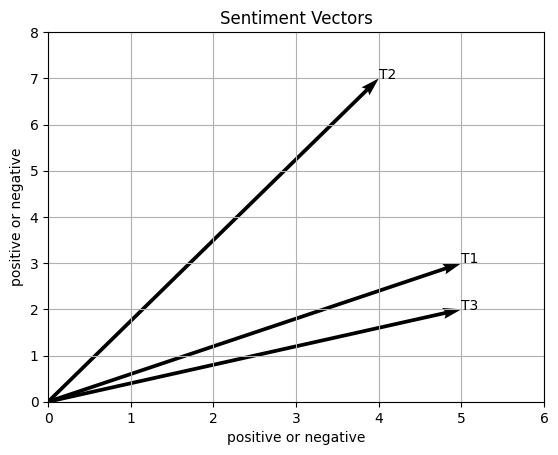

In [27]:
import matplotlib.pyplot as plt

# vec1에 여행자 1의 벡터를 적어주세요
# vec2에 여행자 2의 벡터를 적어주세요
# vec3에 여행자 3의 벡터를 적어주세요
vec1 = [ 5  ,  3 ]
vec2 = [ 4  ,  7 ]
vec3 = [ 5  ,  2 ]

# 벡터 축 정의를 반드시 해주세요
x_label = "positive or negative"
y_label = "positive or negative"


############################
# 아래는 수정하지 않습니다 #
############################

origin = [0, 0]

vectors = {
    "T1": vec1,
    "T2": vec2,
    "T3": vec3,
}

plt.figure()

for label, v in vectors.items():
    plt.quiver(
        origin[0], origin[1],   # 시작점
        v[0], v[1],             # 벡터
        angles='xy',
        scale_units='xy',
        scale=1
    )
    plt.text(v[0], v[1], label)

plt.xlim(0, max(v[0] for v in vectors.values()) + 1)
plt.ylim(0, max(v[1] for v in vectors.values()) + 1)

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("Sentiment Vectors")
plt.grid()
plt.show()

### ***문제3***
- 코사인 유사도를 이용하여 후기의 평점이 비슷할 것으로 보이는 두 여행자의 후기를 고르세요
- 아래 셋 중에 하나를 코사인 유사도 기반으로 고르면 됩니다
  
  (1) 여행자1와 여행자2

  (2) 여행자1와 여행자3

  (3) 여행자2와 여행자3

- 정답을 이곳에 적어주세요
  ```text
  셋 중에 하나 고르기: (2) 여행자1와 여행자3
  이유: 코사인 유사도가 가장 높기 때문
  ```

In [28]:
import math

def cosine(a, b):
    dot = a[0]*b[0] + a[1]*b[1]
    norm_a = math.sqrt(a[0]**2 + a[1]**2)
    norm_b = math.sqrt(b[0]**2 + b[1]**2)
    if norm_a == 0 or norm_b == 0:
        return 0
    return dot / (norm_a * norm_b)

pairs = {
    "여행자1과 여행자2의 코사인 유사도": cosine(vec1, vec2),
    "여행자1과 여행자3의 코사인 유사도": cosine(vec1, vec3),
    "여행자2와 여행자3의 코사인 유사도": cosine(vec2, vec3),
}

pairs

{'여행자1과 여행자2의 코사인 유사도': 0.8721430411136101,
 '여행자1과 여행자3의 코사인 유사도': 0.9872411207126471,
 '여행자2와 여행자3의 코사인 유사도': 0.783110847498294}

### ***문제4***
- 여행자1, 여행자2, 여행자3의 후기를 아래와 같이 벡터로 표현하세요
  - 3개의 축으로 표현합니다
  - 각 축은 긍정단어, 부정단어와 중립단어의 빈도로 표현합니다

In [19]:
# 아래 코드를 실행하여 중립 단어가방을 만들어주세요
words_neutral = []
while True:
    word = input("중립 단어를 추가해주세요(종료: q): ")
    if word == "q":
        break
    words_neutral.append(word)
words_neutral

중립 단어를 추가해주세요(종료: q): 제주
중립 단어를 추가해주세요(종료: q): 바다
중립 단어를 추가해주세요(종료: q): 날씨
중립 단어를 추가해주세요(종료: q): 버스
중립 단어를 추가해주세요(종료: q): 택시
중립 단어를 추가해주세요(종료: q): 비행기
중립 단어를 추가해주세요(종료: q): 관광지
중립 단어를 추가해주세요(종료: q): 숙소
중립 단어를 추가해주세요(종료: q): 카페
중립 단어를 추가해주세요(종료: q): 이동
중립 단어를 추가해주세요(종료: q): q


['제주', '바다', '날씨', '버스', '택시', '비행기', '관광지', '숙소', '카페', '이동']

In [20]:
# 아래 문장을 수정하여 각 여행자의 중립 단어 빈도를 확인해주세요
sentence = """제주의 날씨는 여행 내내 너무 좋았다
숙소에서 보이는 바다뷰가 아름답고 객실도 깨끗해서 만족스러웠다.
관광지에서는 전반적으로 혼잡했지만 친절하게 대해주셨고 사진 찍기에도 좋았다.
버스 시스템이 매우 잘 되어 있어서 이동하는 거리도 생각보다 편했고 여행하는 내내 행복했다.
돌아오는 비행기는 강풍으로 지연이 되기는 했지만 다행히 잘 돌아왔다.
전반적으로 만족스러운 여행이었다"""
neu_freq = {}
for word in words_neutral:
    neu_freq[word]=sentence.count(word)

neu_freq

{'제주': 1,
 '바다': 1,
 '날씨': 1,
 '버스': 1,
 '택시': 0,
 '비행기': 1,
 '관광지': 1,
 '숙소': 1,
 '카페': 0,
 '이동': 1}

In [21]:
# 아래 문장을 수정하여 각 여행자의 중립 단어 빈도를 확인해주세요
sentence = """출발부터 뭔가 심상치 않았다
지연통보를 받았고 공항은 혼잡했다
결국 비행기는 연착되었고 숙소까지 택시를 타고 가야 했다
택시 요금이 비싸게 나왔지만 기사님이 친절했다
관광지는 아름답다고 소문난 곳이어서 만족했다
돌아오는 비행기는 강풍으로 결항되어 숙소를 다시 잡아야 해서 불편했다
그래도 숙소는 깨끗했다
전체적으로 여행이 지루하고 실망스러웠으나 자연의 섭리를 거스를수는 없는 것이다
"""
neu_freq = {}
for word in words_neutral:
    neu_freq[word]=sentence.count(word)

neu_freq

{'제주': 0,
 '바다': 0,
 '날씨': 0,
 '버스': 0,
 '택시': 2,
 '비행기': 2,
 '관광지': 1,
 '숙소': 3,
 '카페': 0,
 '이동': 0}

In [23]:
# 아래 문장을 수정하여 각 여행자의 중립 단어 빈도를 확인해주세요
sentence = """비행기는 정시 운항하여 계획한 일정을 모두 잘 진행할 수 있었다
다양한 관광지에서 색다른 풍경이 인상적이었다
우리나라 최고의 관광지답게 곳곳에서 친절하게 맞이해주셔서 감동적이었다
뚜벅이 여행자라 버스를 이용한 점이 좀 불편했지만 버스 환승이 잘되어 많이 힘들지는 않았다
날씨는 전반적으로 좋았는데 돌아오는날 습도가 높아서 조금 불쾌했던 점을 제외하고는 이 시기에 제주여행은 추천할만 하다
"""
neu_freq = {}
for word in words_neutral:
    neu_freq[word]=sentence.count(word)

neu_freq

{'제주': 1,
 '바다': 0,
 '날씨': 1,
 '버스': 2,
 '택시': 0,
 '비행기': 1,
 '관광지': 2,
 '숙소': 0,
 '카페': 0,
 '이동': 0}

In [24]:
# 아래는 예시입니다
vec_sample = [2,  3, 1]

# x축, y축, z축을 정의하고 각 여행자들의 긍정, 부정빈도를 벡터공간에 표현해주세요
vec1 = [ 5  , 3  , 8  ]
vec2 = [ 4  , 7  , 8  ]
vec3 = [ 5  ,  2 , 7  ]

print(f'여행자1 벡터: {vec1}')
print(f'여행자2 벡터: {vec2}')
print(f'여행자3 벡터: {vec3}')

여행자1 벡터: [5, 3, 8]
여행자2 벡터: [4, 7, 8]
여행자3 벡터: [5, 2, 7]


### ***문제5***
- 아래 코드는 문제1에서 만든 벡터를 그래프로 시각화하는 코드 입니다
- 아래 코드에 주어진 위치에 벡터를 기록하여 2차원 공간에 시각화 하세요
- x, y, z축 정의를 반드시 해주세요
```text
positive
negative
neutral
```

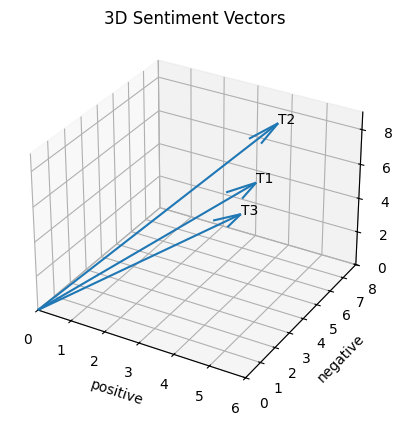

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# vec1, vec2, vec3를 3차원으로 확장해야 함
vec1 = [ 5  , 3  , 8  ]
vec2 = [ 4  , 7  , 8  ]
vec3 = [ 5  ,  2 , 7  ]

x_label = "positive"
y_label = "negative"
z_label = "neutral"

origin = [0, 0, 0]

vectors = {
    "T1": vec1,
    "T2": vec2,
    "T3": vec3,
}

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for label, v in vectors.items():
    ax.quiver(
        origin[0], origin[1], origin[2],   # 시작점
        v[0], v[1], v[2],                  # 벡터
        arrow_length_ratio=0.1
    )
    ax.text(v[0], v[1], v[2], label)

ax.set_xlim(0, max(v[0] for v in vectors.values()) + 1)
ax.set_ylim(0, max(v[1] for v in vectors.values()) + 1)
ax.set_zlim(0, max(v[2] for v in vectors.values()) + 1)

ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_zlabel(z_label)
ax.set_title("3D Sentiment Vectors")

plt.show()

### ***문제6***
- 코사인 유사도를 이용하여 후기의 평점이 비슷할 것으로 보이는 두 여행자의 후기를 고르세요
- 아래 셋 중에 하나를 코사인 유사도 기반으로 고르면 됩니다
  (1) 여행자1와 여행자2

  (2) 여행자1와 여행자3

  (3) 여행자2와 여행자3

- 정답을 이곳에 적어주세요
  ```text
  셋 중에 하나 고르기: (2) 여행자1와 여행자3
  이유: 코사인 유사도가 가장 높기 때문
  ```

In [26]:
import math

def cosine3(a, b):
    dot = a[0]*b[0] + a[1]*b[1] + a[2]*b[2]

    norm_a = math.sqrt(a[0]**2 + a[1]**2 + a[2]**2)
    norm_b = math.sqrt(b[0]**2 + b[1]**2 + b[2]**2)

    if norm_a == 0 or norm_b == 0:
        return 0

    return dot / (norm_a * norm_b)

pairs = {
    "여행자1과 여행자2의 코사인 유사도": cosine3(vec1, vec2),
    "여행자1과 여행자3의 코사인 유사도": cosine3(vec1, vec3),
    "여행자2와 여행자3의 코사인 유사도": cosine3(vec2, vec3),
}

pairs

{'여행자1과 여행자2의 코사인 유사도': 0.9338592095470356,
 '여행자1과 여행자3의 코사인 유사도': 0.9950820986458986,
 '여행자2와 여행자3의 코사인 유사도': 0.8972229068318687}

# ***2. 이미지 처리 영역***

## ***문제1***
- 아래와 같이 "제.png" 파일을 읽었더니 글자가 제대로 나오지 않습니다

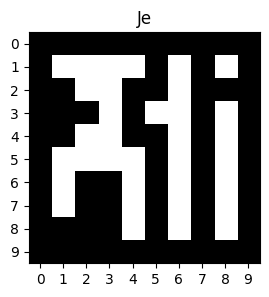

In [29]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


img = Image.open("je.png")
gray = img.convert("L")
arr = np.array(gray)
plt.figure(figsize=(6,3))

h, w = arr.shape
plt.xticks(np.arange(0, w, 1))
plt.yticks(np.arange(0, h, 1))
plt.title("Je")
plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
plt.show()

행렬로 출력해보니 아래와 같습니다

In [30]:
print(arr)

[[  0   0   0   0   0   0   0   0   0   0]
 [  0 255 255 255 255   0 255   0 255   0]
 [  0   0 255 255   0   0 255   0   0   0]
 [  0   0   0 255   0 255 255   0 255   0]
 [  0   0 255 255   0   0 255   0 255   0]
 [  0 255 255 255 255   0 255   0 255   0]
 [  0 255   0   0 255   0 255   0 255   0]
 [  0 255   0   0 255   0 255   0 255   0]
 [  0   0   0   0 255   0 255   0 255   0]
 [  0   0   0   0   0   0   0   0   0   0]]


아래와 같이 나오게 하고 싶습니다

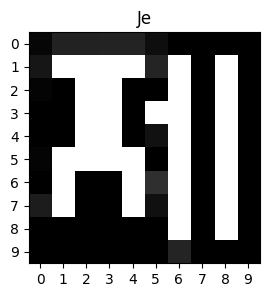

In [ ]:
###############################
# 이 코드는 실행하지 않습니다 #
###############################

아래와 같이 행렬읠 0,0 좌표를 255로 바꾼 결과는 아래와 같습니다

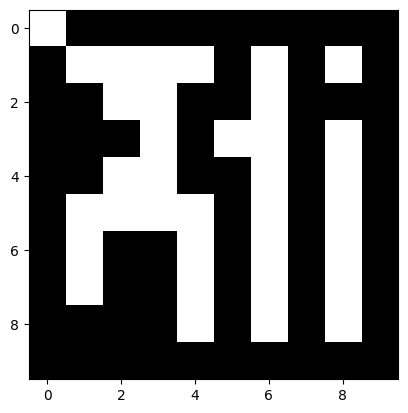

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

arr_new = arr.copy()
arr_new[0,0] = 255
plt.imshow(arr_new, cmap="gray", vmin=0, vmax=255)
plt.show()

아래 코드를 완성하여 목표로 하는 이미지가 나올 수 있게 수정해주세요

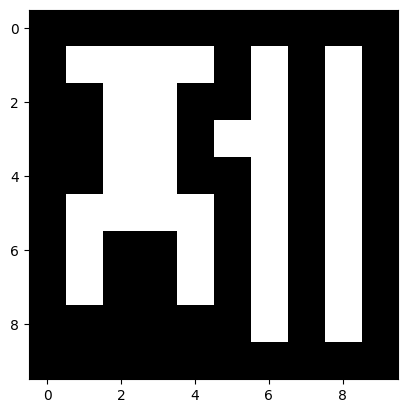

In [31]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

arr_new = arr.copy()

arr_new[ 3  , 2 ] = 255
arr_new[ 2  , 8 ] = 255
arr_new[ 8  , 4 ] = 0

img = Image.fromarray(arr_new.astype(np.uint8))
img.save("je.png")
plt.imshow(arr_new, cmap="gray", vmin=0, vmax=255)
plt.show()

## ***문제2***
아래와 같은 그림을 행렬로 표현하고자 합니다

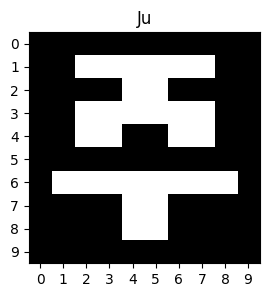

In [ ]:
###############################
# 이 코드는 실행하지 않습니다 #
###############################

아래 행렬을 완성해주세요

저장된 이미지 파일이 위 그림과 동일하게 나오면 정답입니다

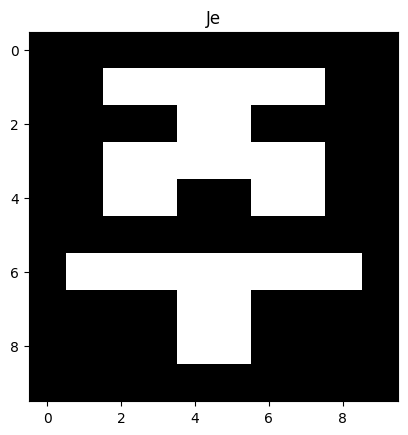

In [32]:
arr_ju = np.array(
[[0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
 [0,   0, 255, 255, 255, 255, 255, 255,   0,   0],
 [0,   0,   0,   0, 255, 255,   0,   0,   0,   0],
 [0,   0, 255, 255, 255, 255, 255, 255,   0,   0],
 [0,   0, 255, 255,   0,   0, 255, 255,   0,   0],
 [0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
 [0, 255, 255, 255, 255, 255, 255, 255, 255,   0],
 [0,   0,   0,   0, 255, 255,   0,   0,   0,   0],
 [0,   0,   0,   0, 255, 255,   0,   0,   0,   0],
 [0,   0,   0,   0,   0,   0,   0,   0,   0,   0]]
)

img = Image.fromarray(arr_ju.astype(np.uint8))
img.save("ju.png")
plt.title("Je")
plt.imshow(arr_ju, cmap="gray", vmin=0, vmax=255)
plt.show()

## ***문제3***

문제1에서 만든 je.png를 읽습니다

이 이미지를 읽으면 행렬이 됩니다

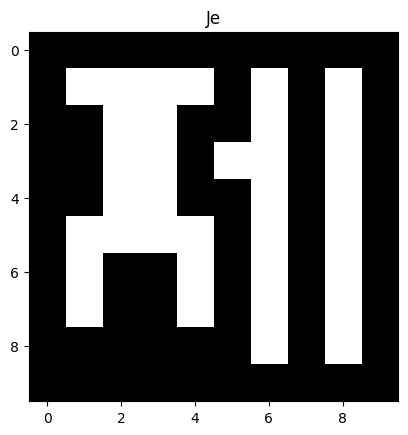

In [33]:
je = Image.open("je.png").convert("L")
je = np.array(je)
plt.title("Je")
plt.imshow(je, cmap="gray", vmin=0, vmax=255)
plt.show()

행렬의 실수배를 이용하여 이미지의 밝기를 조절해봅니다

원본 이미지대비 밝기가 80%인 "제" 행렬과 원본 이미지대비 밝기가 20%인 "주" 행렬을 만들어주세요

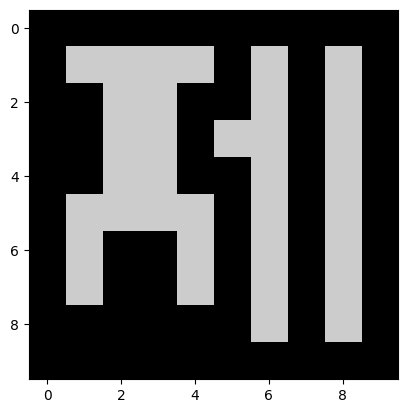

In [35]:
je = Image.open("je.png").convert("L")
je = np.array(je)
je_80 = je*0.8
plt.imshow(je_80, cmap="gray", vmin=0, vmax=255)
plt.show()

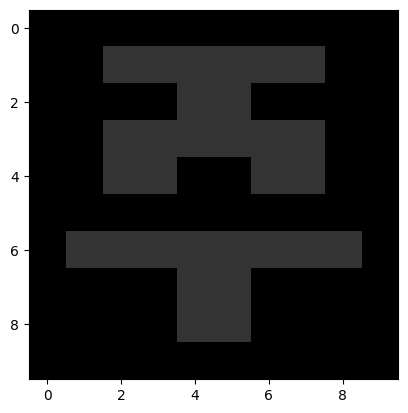

In [36]:
ju = Image.open("ju.png").convert("L")
ju = np.array(ju)
ju_20 = ju*0.2
plt.imshow(ju_20, cmap="gray", vmin=0, vmax=255)
plt.show()

위에서 만든 두 이미지를 합성해봅니다

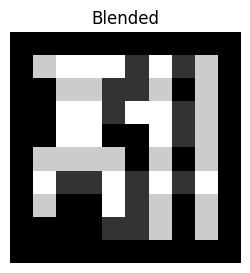

In [37]:
blend = je_80 + ju_20

# 출력
plt.figure(figsize=(3,3))
plt.title(f"Blended")
plt.imshow(blend, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

이번에는 원본 이미지대비 밝기가 20%인 "제" 행렬과 원본 이미지대비 밝기가 80%인 "주" 행렬을 만들어주세요

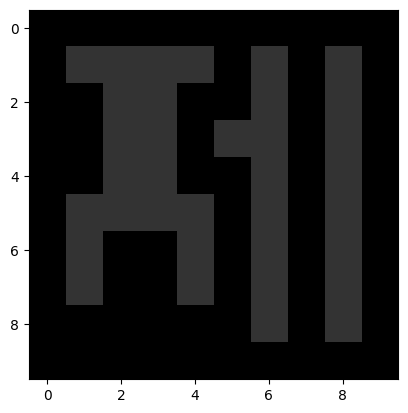

In [38]:
je = Image.open("je.png").convert("L")
je = np.array(je)
je_20 = je*0.2
plt.imshow(je_20, cmap="gray", vmin=0, vmax=255)
plt.show()

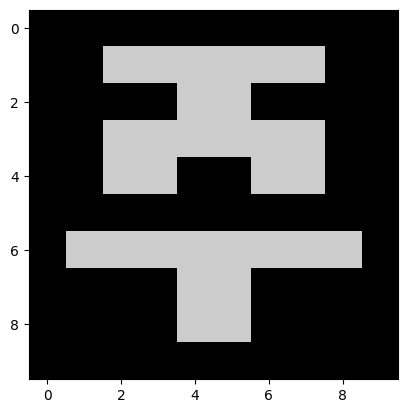

In [39]:
ju = Image.open("ju.png").convert("L")
ju = np.array(ju)
ju_80 = ju*0.8
plt.imshow(ju_80, cmap="gray", vmin=0, vmax=255)
plt.show()

위에서 만든 두 이미지를 합성해봅니다

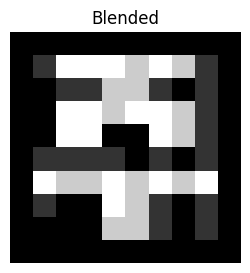

In [40]:
blend = je_20 + ju_80

# 출력
plt.figure(figsize=(3,3))
plt.title(f"Blended")
plt.imshow(blend, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

실수배의 비율이 늘어나는 배열을 만들어봅니다

아래 예제는 0부터 5까지 0과 5를 포함하여 6개의 구간으로 나눕니다

우리는 0부터 1까지 0과 1을 포함하여 101개의 구간으로 만들어봅니다

In [ ]:
# 프레임 생성
alphas = np.linspace(0, 5, 6)
alphas

array([0., 1., 2., 3., 4., 5.])

In [41]:
# 프레임 생성
alphas = np.linspace(0, 1, 101)
alphas

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

이제 이미지를 101번 합성해보겠습니다

합성될 때마다 합성되는 비율이 달라지게 됩니다

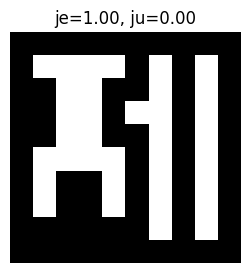

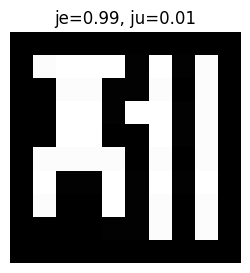

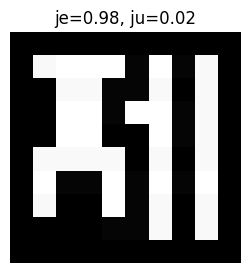

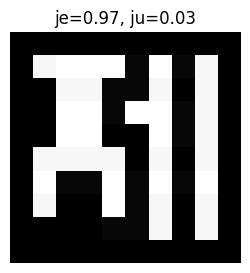

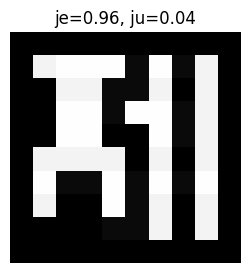

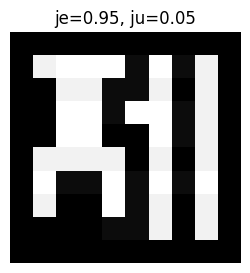

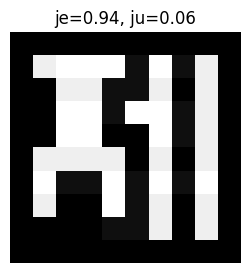

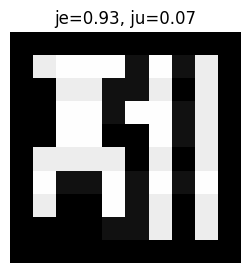

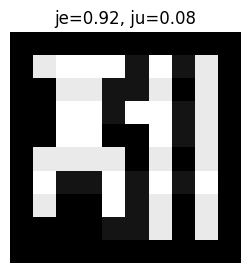

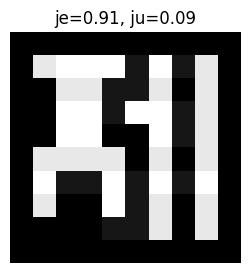

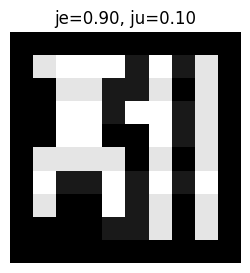

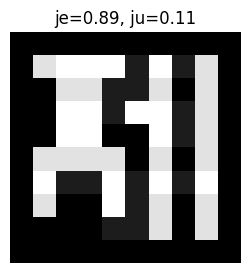

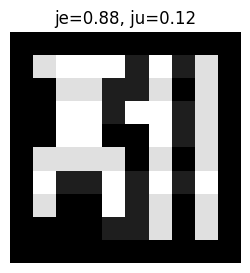

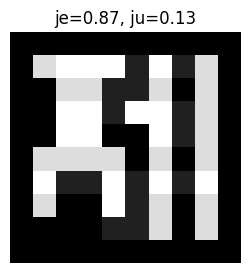

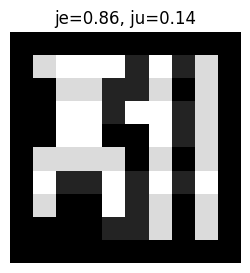

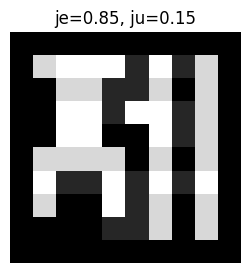

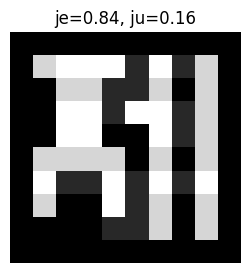

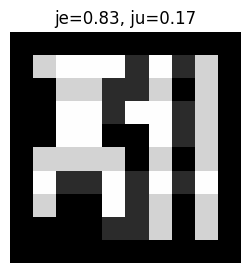

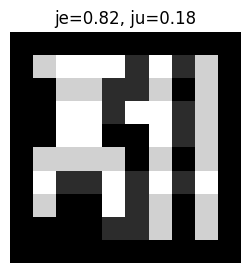

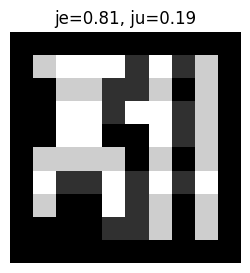

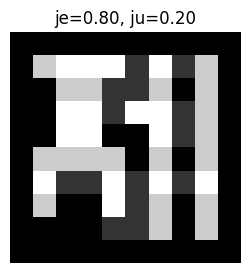

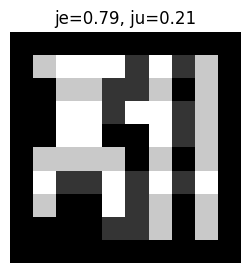

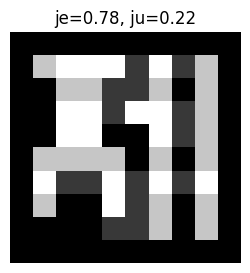

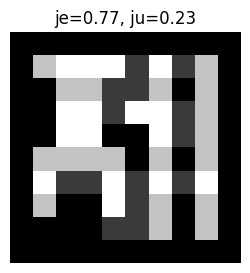

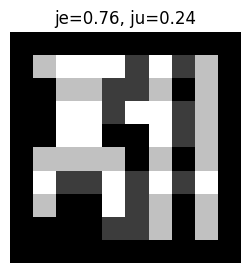

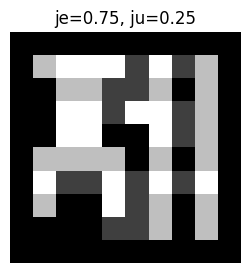

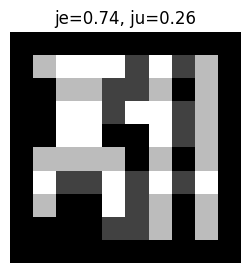

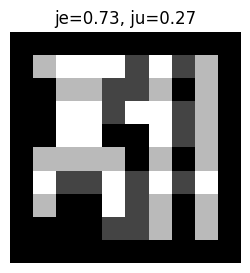

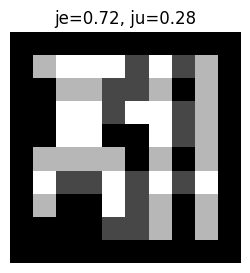

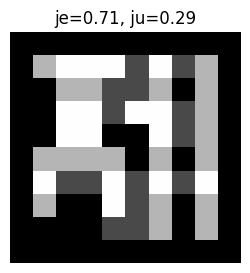

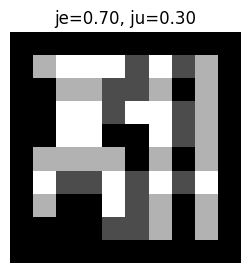

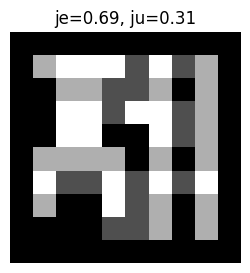

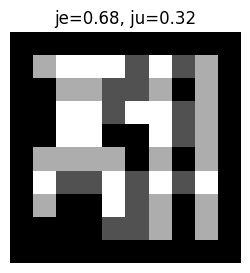

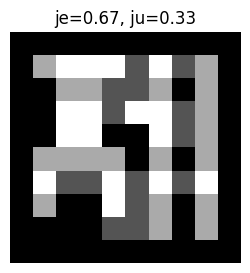

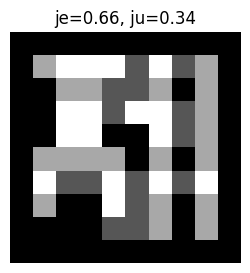

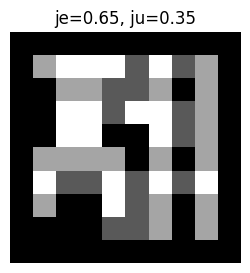

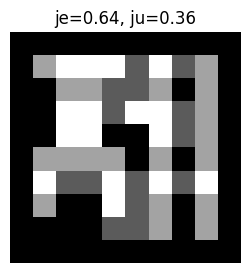

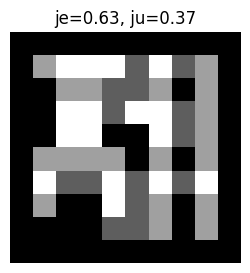

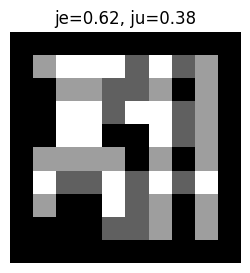

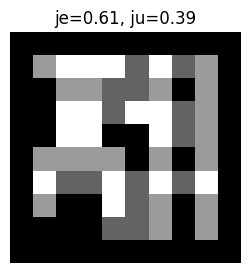

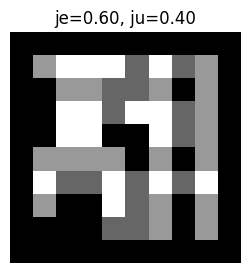

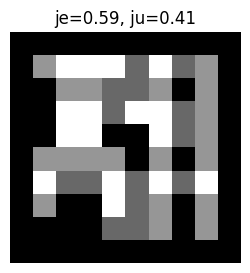

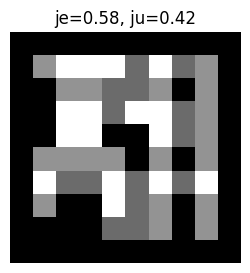

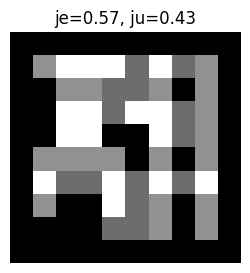

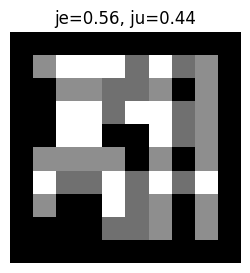

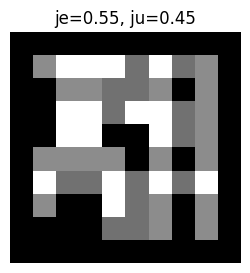

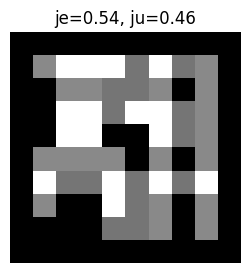

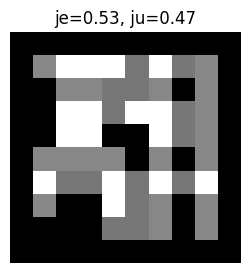

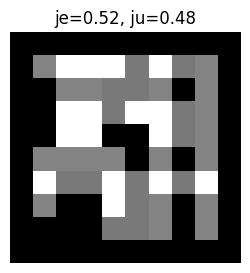

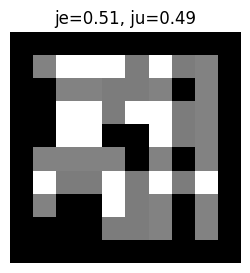

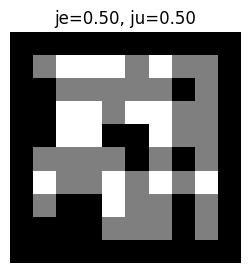

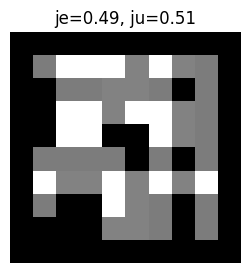

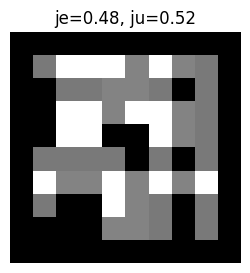

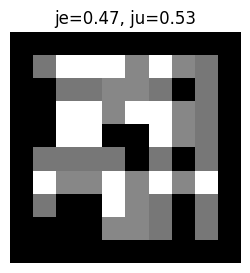

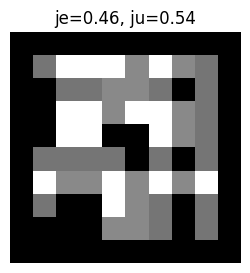

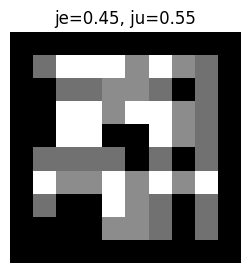

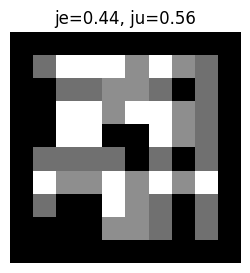

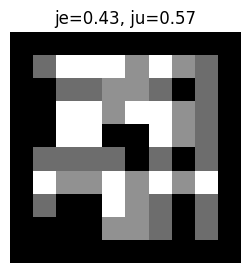

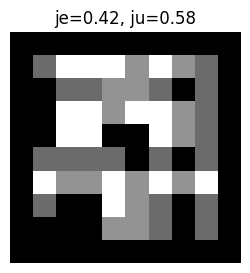

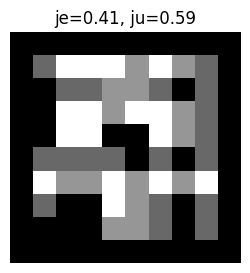

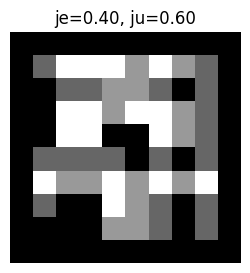

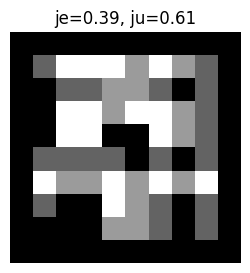

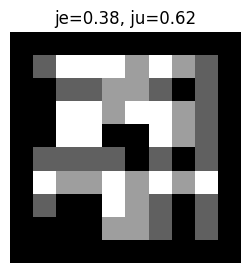

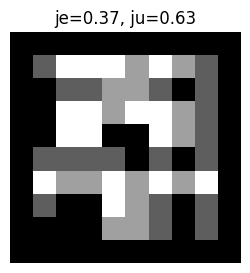

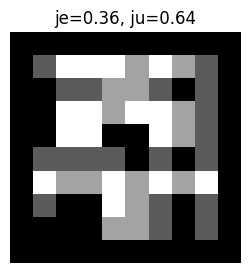

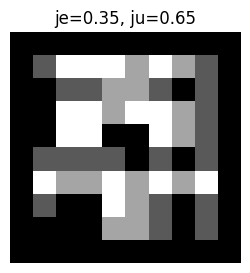

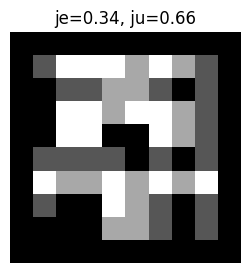

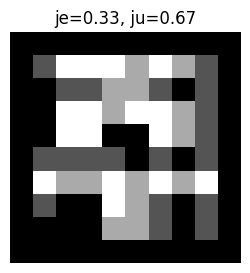

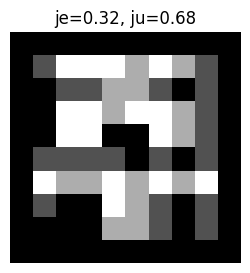

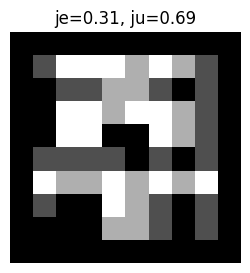

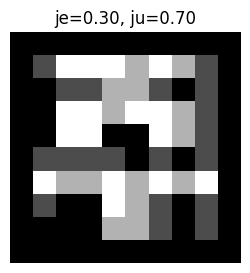

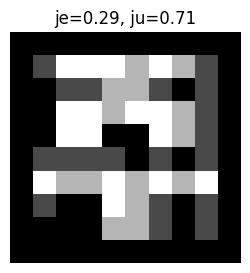

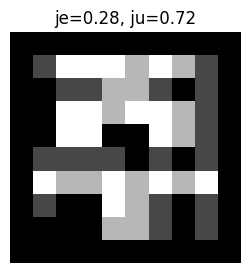

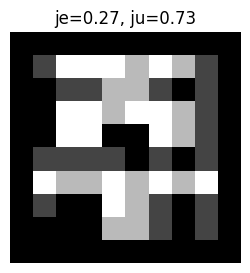

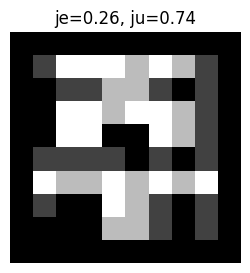

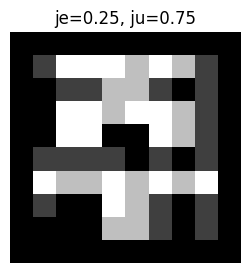

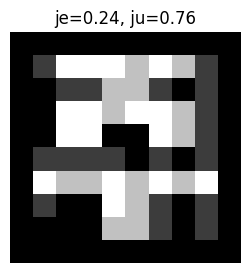

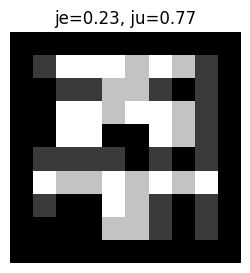

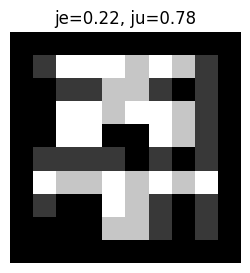

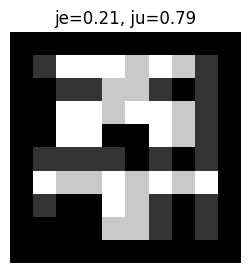

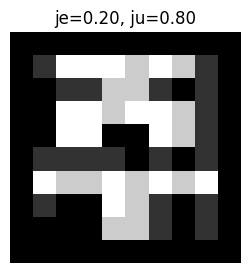

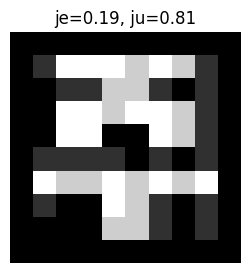

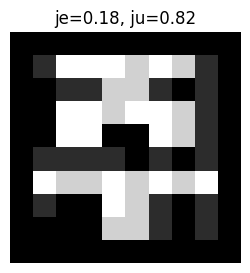

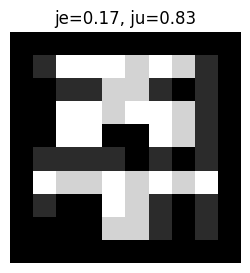

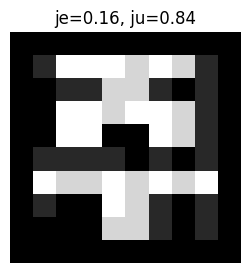

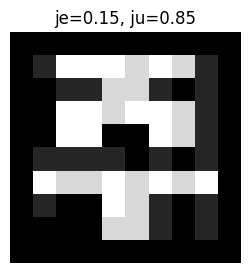

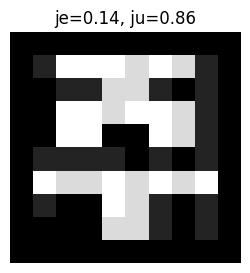

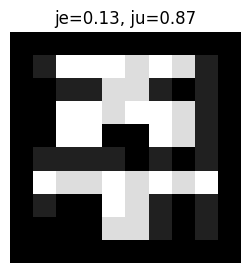

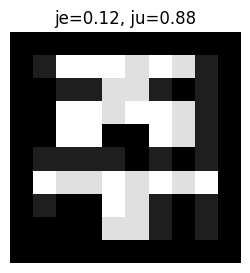

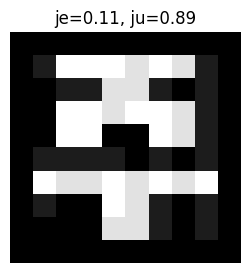

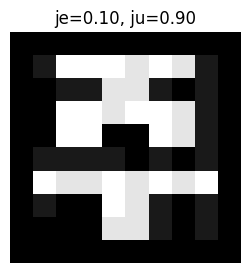

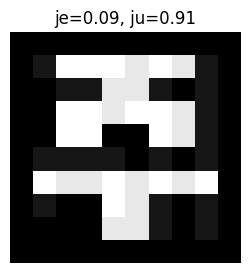

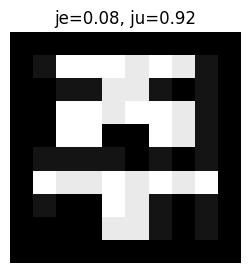

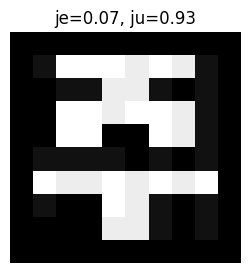

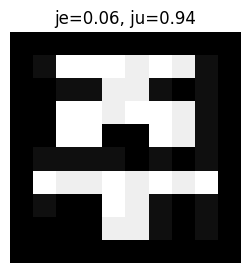

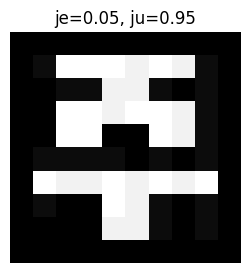

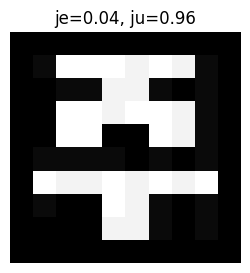

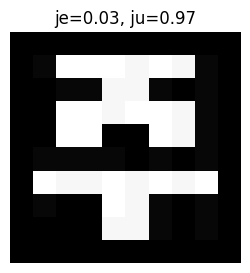

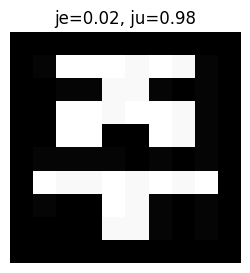

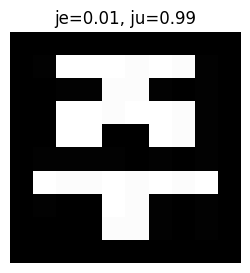

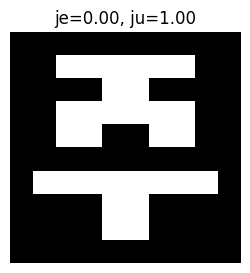

In [42]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 이미지 로드
je = Image.open("je.png").convert("L")
ju = Image.open("ju.png").convert("L")

je = np.array(je).astype(np.float32)
ju = np.array(ju).astype(np.float32)

for i, a in enumerate(alphas):
    # 블렌딩
    blend = (1 - a) * je + a * ju
    blend = np.clip(blend, 0, 255).astype(np.uint8)

    # 출력
    plt.figure(figsize=(3,3))
    plt.title(f"je={1 - a:.2f}, ju={a:.2f}")
    plt.imshow(blend, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

# ***3. 추세선 최적화 영역***
- 아래는 제주관광빅데이터플랫폼에서 확인한 월별 크루즈입도객 데이터 입니다 -
- 출처: https://data.ijto.or.kr/prog/dataPick/bigdata/sub02/view.do?regSn=59

년-월|2026-01|2026-02|2026-03|2026-04|2026-05|
---|---|---|---|---|---|
크루즈입도객|17368|37457|48355|71928|80342


# ***문제1***
임의의 추세선을 정의합니다

이를 위해 먼저 x축 데이터와 이에 따른 y축 데이터를 정의해주세요

```text
x축: 월
y축: 크루즈입도객
```

이후 5개의 점 중에 하나를 지나가는 임의의 추세선을 정의해주세요

In [43]:
import numpy as np

# 데이터
x = np.array([ 1,2,3,4,5                 ])
y = np.array([ 17368,	37457,	48355,	71928,	80342])

# 원점 통과하는 추세선 정의하기
# alpha // beta 는 alpha를 beta로 나눈 몫입니다
a =    48355      //  3

# 추세선 함수를 정의해주세요
# 원점을 지나야 하고 기울기가 위에서 정의한 a가 되어야 합니다
# 그러면 예측값과 오차가 나오게 됩니다
y_pred = a * x


# 이하는 수정하지 않습니다
# 결과 확인 (오차 계산용)
residuals = y - y_pred

print("추세선 계수 a:", a)
print()
print("예측값:", y_pred.round())
print("오차:", residuals.round())

추세선 계수 a: 16118

예측값: [16118 32236 48354 64472 80590]
오차: [1250 5221    1 7456 -248]


추세선을 잘 정의하셨다면 아래 그래프에서 추세선과 오차가 시각화될 것입니다

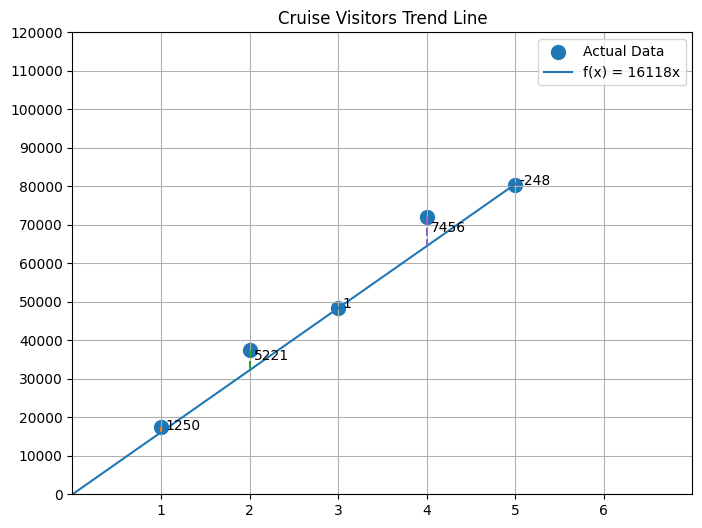

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return a * x

# 그래프용 x
xx = np.linspace(0, 5, 200)

plt.figure(figsize=(8, 6))

# 실제 데이터
plt.scatter(x, y, s=100, label="Actual Data")

# 추세선
plt.plot(xx, f(xx), label=f"f(x) = {a:.0f}x")

# 오차 시각화
for xi, yi in zip(x, y):
    y_pred = f(xi)
    plt.plot([xi, xi], [yi, y_pred], '--', linewidth=1.5)
    plt.text(xi + 0.05, (yi + y_pred) / 2, f"{yi - y_pred:.0f}")

# 축 설정
plt.xticks(np.arange(1, 7, 1))
plt.yticks(np.arange(0, 120001, 10000))

plt.xlim(0, 7)
plt.ylim(0, 120000)

plt.grid(True)
plt.legend()
plt.title("Cruise Visitors Trend Line")
plt.show()

## ***문제2***

우리는 임의의 a를 정의하여 추세선을 정의하였습니다

이제 일반화 시켜보겠습니다

추세선이 $y=ax$ 로 주어졌을 경우 오차는 아래와 같습니다

아래 코드를 실행시켜 보겠습니다

In [45]:
print(f"x = {x}")
print(f"y = {y}")
print(f"y예측값 = a x {x}")
print(f"오차 = {y} -  a x {x}")

x = [1 2 3 4 5]
y = [17368 37457 48355 71928 80342]
y예측값 = a x [1 2 3 4 5]
오차 = [17368 37457 48355 71928 80342] -  a x [1 2 3 4 5]


아래 코드에서 곱하기 기호는 * 기호를 사용합니다

위의 $y$값과 추세선 기울기 $a$를 이용하여 아래 expr를 완성해주세요

그러면 전개된 결과가 나오고 손실함수가 됩니다

손실함수를 출력해주세요

In [46]:
import sympy as sp

a, y = sp.symbols('a y')

expr =( ( 17368 - a )**2  + ( 37457 - 2*a )**2 + ( 48355 - 3*a )**2 + ( 71928 - 4*a )**2 + ( 80342 - 5*a )**2 )  /   5
sp.expand(expr)

11*a**2 - 1853538*a/5 + 15671354446/5

손실함수가 잘 정의되면 아래 코드 실행시 손실함수가 시각화 될 것입니다

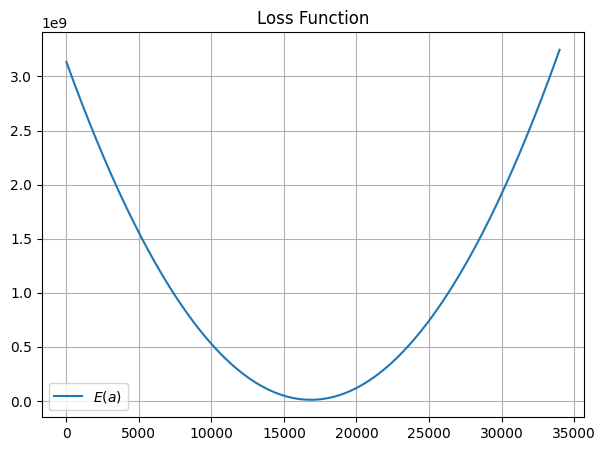

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# x 범위
xx = np.linspace(0, 34000, 200)

# 손실함수
f = sp.lambdify(a, expr, "numpy")

plt.figure(figsize=(7,5))

plt.plot(xx, f(xx), label=r"$E(a)$")

plt.grid(True)
plt.legend()
plt.title("Loss Function")
plt.show()

## ***문제3***

이제 경사하강법을 이용해 a = 30000 으로부터 학습을 진행할 것입니다

초기 a 를 30000으로 정의합니다

In [54]:
a = 30000

손실함수의 수식을 다시 확인해봅니다

In [48]:
sp.expand(expr)

11*a**2 - 1853538*a/5 + 15671354446/5

손실함수를 코드로 표현해보겠습니다

제곱은 **2로 표현합니다

곱하기는 * 기호로 표현합니다

In [49]:
f = lambda a : 11*a**2 - 1853538*a/5 + 15671354446

현재의 손실을 구합니다

In [58]:
loss0 = f(a)
print(f"loss = {loss0}")

loss = 14450126446.0


학습률을 정의합니다

In [67]:
eta = 0.01

손실함수의 도함수를 정의해주세요

In [50]:
df = lambda a : 22*a - 1853538/5

아래 두번의 학습동안 손실이 줄어드는 eta를 구하세요

In [68]:
grad = df(a)
a1 = a - eta * grad
loss1 = f(a1)
print(f"step1 a ={a1}")
print(f"loss = {loss1}")

step1 a =27107.076
loss = 13705284620.989937


In [69]:
grad = df(a1)
a2 = a1 - eta * grad
loss2 = f(a2)
print("step2 a =", a2)
print(f"loss = {f(loss2)}")

step2 a = 24850.59528
loss = 1.9318014490562304e+21


아래 코드를 실행시켜서 모두 True가 나오면 성공입니다

In [70]:
print(f'1회 학습 후 최초 loss보다 loss가 감소했는가: {True if loss0 > loss1 else False}')
print(f'2회 학습 후 이전보다 loss가 감소했는가: {True if loss1 > loss2 else False}')

1회 학습 후 최초 loss보다 loss가 감소했는가: True
2회 학습 후 이전보다 loss가 감소했는가: True
